# 03 Exploratory Data Analysis

Use this notebook to explore trends, distributions, segments, anomalies, and early business signals.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()

In [2]:
DATA_PATH = PROJECT_ROOT / 'data/processed/cleaned_dataset.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,150000.0,NaN,NaN,NaN,175000.5,43301.414527,100001.0,137500.75,175000.5,212500.25,250000.0
age,150000.0,NaN,NaN,NaN,21.00038,2.581216,17.0,19.0,21.0,23.0,25.0
gender,150000,3,Other,50048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
course,150000,6,MBA,25231,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,150000,4,1st,37680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_study_hours,150000.0,NaN,NaN,NaN,5.507869,2.595592,1.0,3.3,5.5,7.7,10.0
daily_sleep_hours,150000.0,NaN,NaN,NaN,6.499361,1.443859,4.0,5.2,6.5,7.7,9.0
screen_time_hours,150000.0,NaN,NaN,NaN,6.502819,3.178948,1.0,3.7,6.5,9.3,12.0
stress_level,150000,3,High,50295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anxiety_score,150000.0,NaN,NaN,NaN,5.493907,2.872607,1.0,3.0,5.0,8.0,10.0


## 1. Distribution of Key Variables


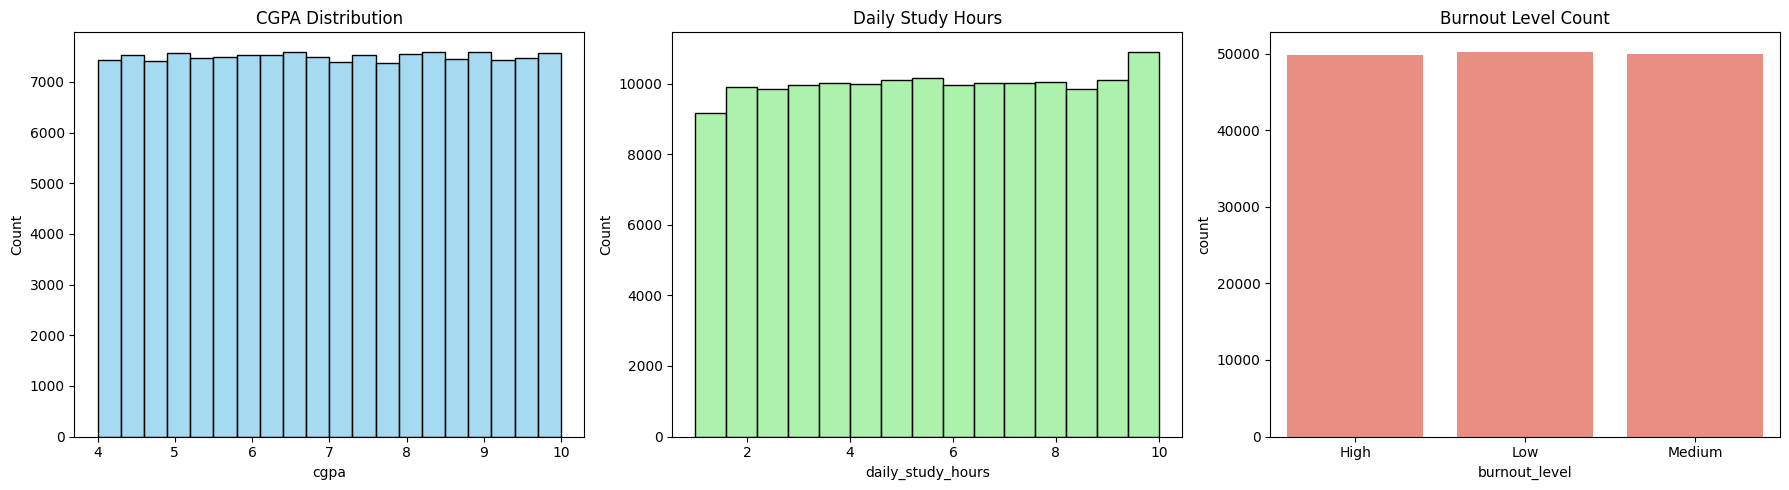

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['cgpa'], bins=20, ax=axes[0], color='skyblue').set_title('CGPA Distribution')
sns.histplot(df['daily_study_hours'], bins=15, ax=axes[1], color='lightgreen').set_title('Daily Study Hours')
sns.countplot(data=df, x='burnout_level', ax=axes[2], color='salmon').set_title('Burnout Level Count')
plt.tight_layout()
plt.show()

## 2. Correlation Matrix


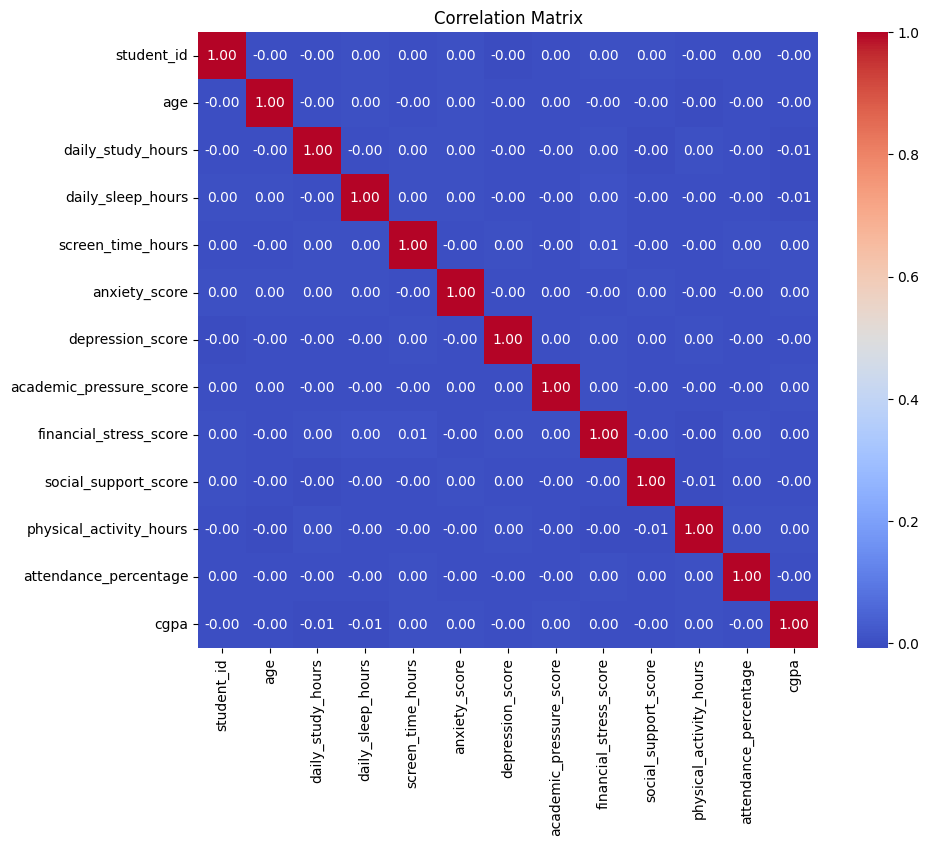

In [5]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 3. Burnout vs Study Hours


/var/folders/fw/jycr5jkj1xjgrgfzgxdc0v940000gn/T/ipykernel_83028/4294782281.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='burnout_level', y='daily_study_hours', palette='Set2')


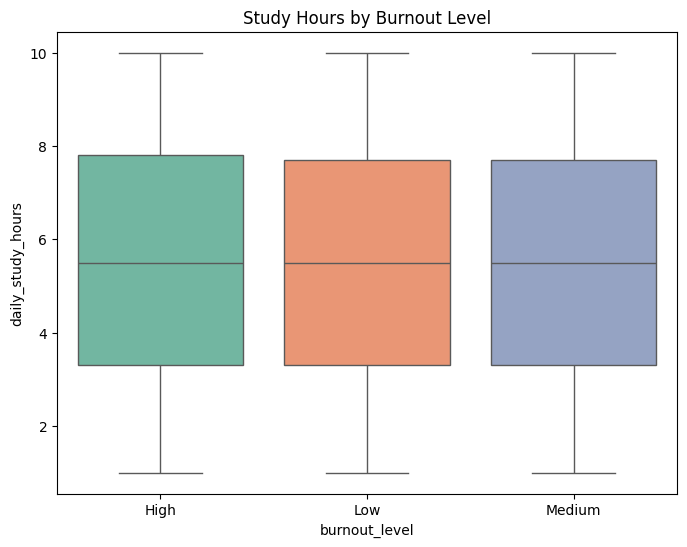

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='burnout_level', y='daily_study_hours', palette='Set2')
plt.title('Study Hours by Burnout Level')
plt.show()